# Do Zambian Elections Move the Kwacha?
## An Event-Study Analysis of Exchange Rate Responses to General Elections, 2006–2021
## With a Forward-Looking Assessment of 2026

**Author:** Boldwin Mweemba  
**Affiliation:** FSI Outsourcing, Lusaka, Zambia | MSc Financial Engineering candidate, WorldQuant University  
**GitHub:** [BoldwinMax](https://github.com/BoldwinMax)  
**Date:** June 2026

---

## Abstract

This notebook investigates whether Zambian general elections produce statistically significant abnormal movements in the ZMW/USD exchange rate. Using daily Bank of Zambia interbank midrate data from January 2006 to June 2026, we apply a standard event-study methodology to six electoral events (four general elections and two presidential by-elections). We compute Cumulative Abnormal Returns (CARs) over a ±20 trading day window around each election date, benchmarked against a 100-day pre-election estimation window.

We find that the 2021 regime-change election produced the largest and most statistically significant exchange rate response in the sample (CAR = −0.35, p = 0.002), with appreciation beginning two weeks before polling day — consistent with markets pricing in a shift in the fiscal and reform trajectory. The 2015 presidential by-election produced mild but marginally significant post-result depreciation (p = 0.071). Four other elections produced no statistically significant abnormal returns. These results suggest that the Kwacha responds to *credibility signals* rather than electoral uncertainty per se. We close with a directional assessment of the August 2026 general election.

---

## 1. Introduction and Motivation

The Zambian Kwacha (ZMW) is one of sub-Saharan Africa's most volatile emerging market currencies, driven primarily by copper prices, foreign exchange reserves, and fiscal credibility signals. Zambia holds general elections every five years under a presidential system, with the most recent election scheduled for **August 2026**.

A natural question for investors, policymakers, and analysts is: **do elections themselves move the Kwacha?** If so, when — before or after polling day? And does the *direction* of the move depend on who wins?

### 1.1 Why This Matters

- **Investors and pension funds** (including NAPSA) hold foreign-denominated liabilities. A sharp pre-election FX move can materially affect portfolio valuations.
- **Bank of Zambia** may intervene to smooth electoral volatility, making the absence of a signal as informative as its presence.
- **The 2026 election** is approaching in a context of IMF programme compliance, recovering reserves (reported at USD 6.5 billion in mid-2026), and a completed sovereign debt restructuring process — a materially different macroeconomic backdrop than any previous election in the sample.

### 1.2 Research Questions

1. **Q1 — Does an election signal matter at all?** Is the Kwacha's behaviour around elections statistically different from its baseline?
2. **Q2 — Does uncertainty or outcome drive the move?** Is it the pre-election window (uncertainty) or post-result window (regime signal) that matters?
3. **Q3 — Does it matter who wins?** Do regime-change elections differ from incumbent-retention elections?
4. **Q4 — What should we expect in 2026?** Given the patterns in Q1–Q3, what is the directional assessment for the upcoming election?

### 1.3 Contribution

To our knowledge, this is the first systematic event-study of Zambian electoral FX effects. The analysis directly extends prior work on ZMW determinants (Mweemba, 2025), which found that FX reserves explain approximately 50% of Kwacha movements. This paper asks whether the *residual* 50% is partly explained by electoral signals.

---

## 2. Data

### 2.1 Exchange Rate Data

- **Source:** Bank of Zambia (BoZ) — Daily Average Interbank Exchange Rates
- **Series:** ZMW/USD daily midrate (average of buy and sell)
- **Coverage:** 3 January 2006 to 15 June 2026 (5,074 trading days)
- **Note on rebase:** Zambia redenominated its currency on 1 January 2013 (1 new Kwacha = 1,000 old Kwacha). The raw BoZ file contains old Kwacha values prior to this date; we divide pre-2013 values by 1,000 to produce a consistent series.

### 2.2 Election Events

| ID | Date | Winner | Party | Regime Change | Type |
|---|---|---|---|---|---|
| 1 | 28 Sep 2006 | Mwanawasa | MMD | No | General |
| 2 | 30 Oct 2008 | Banda | MMD | No | By-election |
| 3 | 20 Sep 2011 | Sata | PF | **Yes** | General |
| 4 | 20 Jan 2015 | Lungu | PF | No | By-election |
| 5 | 11 Aug 2016 | Lungu | PF | No | General |
| 6 | 12 Aug 2021 | Hichilema | UPND | **Yes** | General |

### 2.3 Limitations

- **Small sample:** Six events is a small sample. Statistical significance must be interpreted cautiously.
- **BoZ intervention:** The Bank of Zambia intervenes in the FX market, potentially suppressing signals.
- **2008 confound:** The 2008 by-election coincided with the global financial crisis (Lehman Brothers collapse), making it difficult to isolate the electoral signal.
- **No copper price control:** This analysis does not explicitly control for copper price movements during the event windows.

---

## 3. Methodology

We follow the standard event-study framework applied to currency markets.

### 3.1 Event Windows

- **Estimation window:** Trading days −120 to −21 relative to election day (approximately 100 trading days)
- **Event window:** Trading days −20 to +20 (41 trading days total)
- Day 0 is defined as the nearest trading day on or after the election date

### 3.2 Expected Returns

The expected (normal) daily log return is estimated as the **mean log return** over the estimation window:

$$\hat{\mu} = \frac{1}{T}\sum_{t \in \text{estimation}} r_t$$

where $r_t = \ln(S_t / S_{t-1})$ and $S_t$ is the ZMW/USD midrate.

### 3.3 Abnormal Returns and CARs

$$AR_t = r_t - \hat{\mu}$$

$$CAR_{[t_1, t_2]} = \sum_{t=t_1}^{t_2} AR_t$$

**Sign convention:** Positive CAR = Kwacha *depreciation* (more Kwacha per dollar). Negative CAR = Kwacha *appreciation*.

### 3.4 Statistical Inference

We compute a t-statistic on the full-window CAR using the standard deviation of the abnormal return series itself (heteroskedasticity-robust):

$$t = \frac{CAR_{[-20,+20]}}{\hat{\sigma}_{AR} \cdot \sqrt{N}}$$

where $\hat{\sigma}_{AR}$ is the standard deviation of the AR series and $N$ is the number of days in the event window. P-values are computed from the t-distribution with $N-1$ degrees of freedom.


---
## 4. Data Loading and Preparation

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: IMPORTS AND DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
# Standard scientific Python stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: LOAD AND CLEAN BOZ DAILY EXCHANGE RATE DATA
# ─────────────────────────────────────────────────────────────────────────────
# The BoZ file has two header rows:
#   Row 0: currency names (Dollar, Pound, Euro, Rand)
#   Row 1: Buy / Sale labels
# Data begins at row 2. Column 0 is empty; column 1 is Date.
# We only need USD (columns 2 and 3).

raw = pd.read_excel("AVERAGE_FXRATES.xlsx", header=None)
df  = raw.iloc[2:].reset_index(drop=True)   # skip header rows
df  = df[[1, 2, 3]].copy()
df.columns = ['Date', 'USD_Buy', 'USD_Sell']

# Parse types
df['Date']     = pd.to_datetime(df['Date'], errors='coerce')
df['USD_Buy']  = pd.to_numeric(df['USD_Buy'],  errors='coerce')
df['USD_Sell'] = pd.to_numeric(df['USD_Sell'], errors='coerce')

# Compute midrate as average of buy and sell
df['USD_Mid'] = (df['USD_Buy'] + df['USD_Sell']) / 2
df = df[['Date', 'USD_Mid']].dropna().sort_values('Date').reset_index(drop=True)

# ── CURRENCY REBASE CORRECTION ───────────────────────────────────────────────
# Zambia redenominated on 1 January 2013:
#   1 new Kwacha = 1,000 old Kwacha
# The BoZ file stores pre-2013 data in OLD Kwacha (values ~3,000–5,000).
# We divide by 1,000 to convert to new Kwacha throughout.
# Crossover confirmed at 2013-01-01: last old-Kwacha value ~4,988 (28 Dec 2012),
# first new-Kwacha value ~5.216 (2 Jan 2013).

rebase_date = pd.Timestamp('2013-01-01')
df.loc[df['Date'] <= rebase_date, 'USD_Mid'] /= 1000

# ── LOG RETURNS ──────────────────────────────────────────────────────────────
# We work with log returns: r_t = ln(S_t / S_{t-1})
# This is standard in FX event studies and ensures returns are symmetric
# and approximately normally distributed.
df['log_return'] = np.log(df['USD_Mid'] / df['USD_Mid'].shift(1))
df = df.dropna(subset=['log_return']).reset_index(drop=True)

print(f"Dataset ready.")
print(f"  Observations : {len(df):,}")
print(f"  Date range   : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"  Mean daily return : {df['log_return'].mean():.6f}")
print(f"  Daily return std  : {df['log_return'].std():.6f}")

# Yearly average rate — sanity check for the rebase correction
print("\nYearly average ZMW/USD (new Kwacha throughout):")
print(df.groupby(df['Date'].dt.year)['USD_Mid'].mean().round(2).to_string())

Dataset ready.
  Observations : 5,074
  Date range   : 2006-01-04 to 2026-06-15
  Mean daily return : 0.000318
  Daily return std  : 0.038295

Yearly average ZMW/USD (new Kwacha throughout):
Date
2006     4.05
2007     4.00
2008     3.75
2009     5.04
2010     4.80
2011     4.86
2012     5.14
2013     5.39
2014     6.15
2015     8.70
2016    10.31
2017     9.53
2018    10.47
2019    12.92
2020    18.31
2021    19.92
2022    16.91
2023    20.23
2024    26.19
2025    25.22
2026    19.09


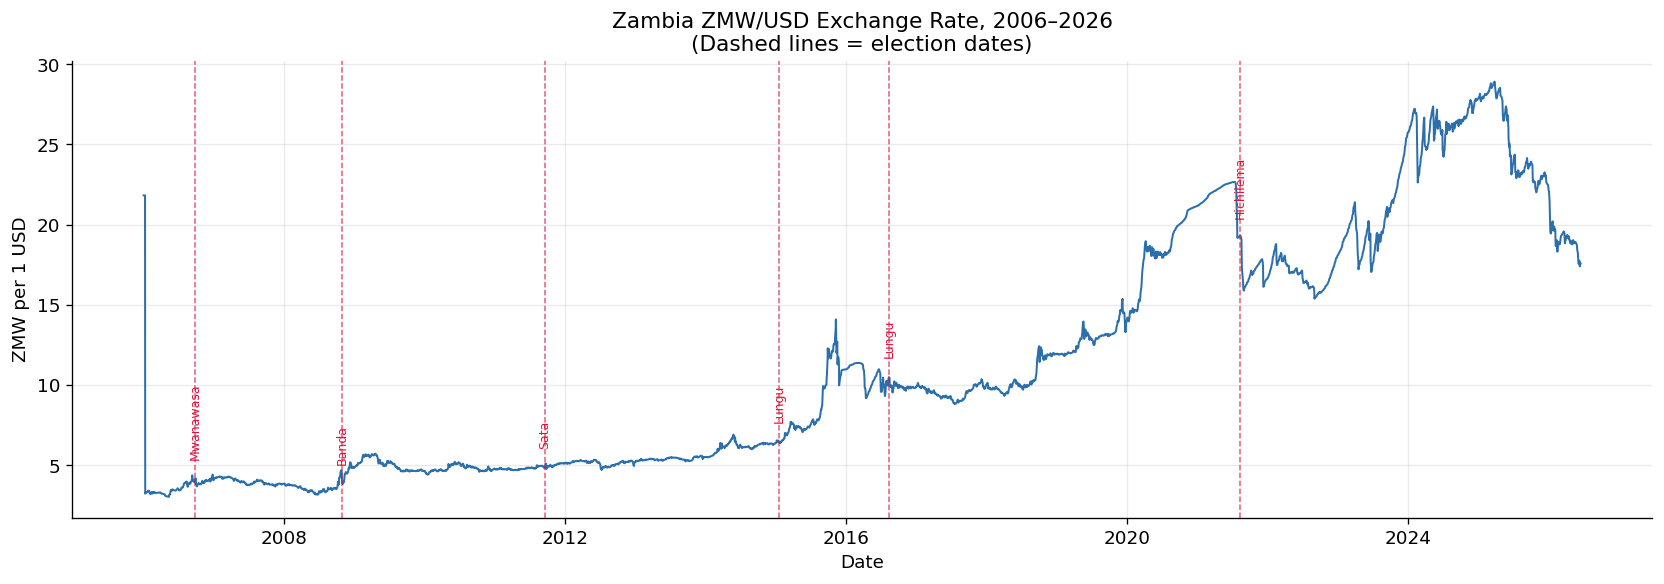

Figure 1 saved.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: PLOT THE FULL ZMW/USD TIME SERIES
# ─────────────────────────────────────────────────────────────────────────────
# This gives us visual context before the event study:
# the Kwacha has depreciated from ~3.8 in 2006 to a peak of ~28 in 2025,
# with key structural breaks around 2015 (debt crisis) and 2021 (UPND election).

election_dates = [
    ('2006-09-28', 'Mwanawasa\n(MMD)',     0.3),
    ('2008-10-30', 'Banda\n(MMD)',         0.3),
    ('2011-09-20', 'Sata\n(PF)',           0.3),
    ('2015-01-20', 'Lungu\n(PF)',          0.3),
    ('2016-08-11', 'Lungu\n(PF)',          0.3),
    ('2021-08-12', 'Hichilema\n(UPND)',    0.3),
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df['USD_Mid'], color='#2c6fad', linewidth=1.2, label='ZMW/USD midrate')

for ed, label, _ in election_dates:
    ax.axvline(pd.Timestamp(ed), color='crimson', linewidth=0.9, linestyle='--', alpha=0.7)

# Annotate election years only
for ed, label, _ in election_dates:
    y_pos = df[df['Date'] >= ed]['USD_Mid'].iloc[0] if len(df[df['Date'] >= ed]) > 0 else 1
    ax.text(pd.Timestamp(ed), y_pos + 1.2, label.split('\n')[0],
            fontsize=7.5, color='crimson', ha='center', rotation=90, va='bottom')

ax.set_xlabel('Date')
ax.set_ylabel('ZMW per 1 USD')
ax.set_title('Zambia ZMW/USD Exchange Rate, 2006–2026\n(Dashed lines = election dates)', fontsize=13)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('fig1_zmw_usd_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: DEFINE ELECTION EVENTS
# ─────────────────────────────────────────────────────────────────────────────
# Six electoral events from 2006 to 2021.
# The 2001 election is excluded (no reliable daily data prior to 2006).
# regime_change = 1 if the ruling party changed, 0 otherwise.

elections = pd.DataFrame({
    'election_id':   [1,            2,            3,            4,            5,            6          ],
    'date':          ['2006-09-28', '2008-10-30', '2011-09-20', '2015-01-20', '2016-08-11', '2021-08-12'],
    'winner':        ['Mwanawasa',  'Banda',      'Sata',       'Lungu',      'Lungu',      'Hichilema'],
    'party':         ['MMD',        'MMD',        'PF',         'PF',         'PF',         'UPND'     ],
    'regime_change': [0,            0,             1,            0,            0,             1         ],
    'election_type': ['general',    'by-election', 'general',    'by-election','general',    'general' ],
    'notes': [
        'Comfortable Mwanawasa re-election, stable economic period',
        'Mwanawasa died in office; Banda wins; coincides with global financial crisis',
        'Historic: MMD loses power after 20 years; Sata wins',
        'Incumbent died in office; successor wins narrow contested by-election',
        'Incumbent re-elected in highly contested result; constitutional uncertainty',
        'Regime change; incoming government signalled debt restructuring and fiscal reform',
    ]
})
elections['date'] = pd.to_datetime(elections['date'])

print("Election events:")
print(elections[['election_id','date','winner','party','regime_change','election_type']].to_string(index=False))

# Verify data coverage for each election
print("\nData coverage check (trading days available):")
EST_START, EST_END = -120, -21
EVT_START, EVT_END = -20,  +20

for _, row in elections.iterrows():
    ed  = row['date']
    t0  = df[df['Date'] >= ed].index[0]
    est = df.loc[t0 + EST_START : t0 + EST_END]
    evt = df.loc[t0 + EVT_START : t0 + EVT_END]
    print(f"  Election {row['election_id']} ({ed.date()}) | "
          f"estimation={len(est)} days | event={len(evt)} days | "
          f"actual election date in data: {df.loc[t0, 'Date'].date()}")

Election events:
 election_id       date    winner party  regime_change election_type
           1 2006-09-28 Mwanawasa   MMD              0       general
           2 2008-10-30     Banda   MMD              0   by-election
           3 2011-09-20      Sata    PF              1       general
           4 2015-01-20     Lungu    PF              0   by-election
           5 2016-08-11     Lungu    PF              0       general
           6 2021-08-12 Hichilema  UPND              1       general

Data coverage check (trading days available):
  Election 1 (2006-09-28) | estimation=100 days | event=41 days | actual election date in data: 2006-09-29
  Election 2 (2008-10-30) | estimation=100 days | event=41 days | actual election date in data: 2008-10-31
  Election 3 (2011-09-20) | estimation=100 days | event=41 days | actual election date in data: 2011-09-21
  Election 4 (2015-01-20) | estimation=100 days | event=41 days | actual election date in data: 2015-01-21
  Election 5 (2016-08-11)

---
## 5. Event Study: Computing Abnormal Returns

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5: COMPUTE ABNORMAL RETURNS AND CARs FOR ALL ELECTIONS
# ─────────────────────────────────────────────────────────────────────────────
# Methodology:
#   1. Estimate the 'normal' daily log return as the mean over days [-120, -21]
#   2. Abnormal return on day t = actual return - normal return
#   3. CAR = cumulative sum of abnormal returns over the event window
#   4. t-statistic uses the std of the AR series itself (robust to heteroskedasticity)
#
# Sign convention throughout:
#   Positive CAR → Kwacha DEPRECIATION (more ZMW per USD)
#   Negative CAR → Kwacha APPRECIATION (fewer ZMW per USD)

results = {}

for _, row in elections.iterrows():
    eid = row['election_id']
    ed  = row['date']

    # Locate election day in the dataset (nearest trading day on or after)
    t0 = df[df['Date'] >= ed].index[0]

    # Slice estimation and event windows
    est = df.loc[t0 + EST_START : t0 + EST_END, 'log_return']
    evt = df.loc[t0 + EVT_START : t0 + EVT_END, 'log_return']

    if len(est) < 50 or len(evt) < 10:
        print(f"  Election {eid}: insufficient data — skipped")
        continue

    # Normal return parameters from estimation window
    mu    = est.mean()   # expected daily return
    sigma = est.std()    # daily return volatility in estimation window

    # Abnormal returns and CARs
    ar  = evt - mu
    car = ar.cumsum()

    # Split into pre-election (days -20 to -1) and post-election (days 0 to +20)
    # Note: index 0–19 = pre-election, index 20–40 = post-election
    car_pre  = ar.iloc[:20].sum()   # days -20 to -1
    car_post = ar.iloc[20:].sum()   # days  0  to +20

    # Robust t-statistic: use std of the AR series
    ar_std = ar.std()
    t_stat = car.iloc[-1] / (ar_std * np.sqrt(len(evt))) if ar_std > 0 else np.nan
    p_val  = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(evt)-1)) if not np.isnan(t_stat) else np.nan

    results[eid] = {
        'winner':        row['winner'],
        'party':         row['party'],
        'regime_change': row['regime_change'],
        'election_type': row['election_type'],
        'notes':         row['notes'],
        'date':          row['date'],
        'est_dates':     df.loc[t0 + EST_START : t0 + EST_END, 'Date'],
        'evt_dates':     df.loc[t0 + EVT_START : t0 + EVT_END, 'Date'],
        'ar':            ar,
        'car':           car,
        'car_pre':       car_pre,
        'car_post':      car_post,
        'car_final':     car.iloc[-1],
        't_stat':        t_stat,
        'p_val':         p_val,
        'mu':            mu,
        'sigma':         sigma,
        'n_est':         len(est),
        'n_evt':         len(evt),
    }

print(f"Event study complete. {len(results)} elections processed.")

Event study complete. 6 elections processed.


---
## 6. Results

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6: RESULTS TABLE
# ─────────────────────────────────────────────────────────────────────────────
# CAR_pre  = CAR over days -20 to -1 (pre-election uncertainty period)
# CAR_post = CAR over days  0  to +20 (post-result reaction period)
# CAR_full = total CAR over the full [-20, +20] window
# t, p     = test statistic and p-value for H0: CAR_full = 0
# Significance: *** p<0.01, ** p<0.05, * p<0.10

print("Table 1: Cumulative Abnormal Returns Around Zambian Elections")
print("(Positive CAR = Kwacha depreciation; Negative = appreciation)")
print()
print(f"{'ID':<4} {'Date':<12} {'Winner':<12} {'Regime':<7} {'Type':<12} "
      f"{'CAR_pre':>8} {'CAR_post':>9} {'CAR_full':>9} {'t':>7} {'p':>6} {'Sig':>4}")
print("-" * 97)

for eid, r in results.items():
    sig = ('***' if r['p_val'] < 0.01 else
           '**'  if r['p_val'] < 0.05 else
           '*'   if r['p_val'] < 0.10 else '')
    print(f"{eid:<4} {str(r['date'].date()):<12} {r['winner']:<12} {r['regime_change']:<7} "
          f"{r['election_type']:<12} "
          f"{r['car_pre']:>+.4f}  {r['car_post']:>+.4f}  {r['car_final']:>+.4f}  "
          f"{r['t_stat']:>+.2f}  {r['p_val']:.3f}  {sig}")

print()
print("Notes: Significance levels: *** p<0.01, ** p<0.05, * p<0.10")
print("       Estimation window: trading days -120 to -21 relative to election day")
print("       Event window: trading days -20 to +20")

Table 1: Cumulative Abnormal Returns Around Zambian Elections
(Positive CAR = Kwacha depreciation; Negative = appreciation)

ID   Date         Winner       Regime  Type          CAR_pre  CAR_post  CAR_full       t      p  Sig
-------------------------------------------------------------------------------------------------
1    2006-09-28   Mwanawasa    0       general      -0.0184  -0.0704  -0.0888  -0.59  0.560  
2    2008-10-30   Banda        0       by-election  +0.2610  -0.0399  +0.2211  +0.95  0.346  
3    2011-09-20   Sata         1       general      -0.0347  +0.0343  -0.0004  -0.01  0.995  
4    2015-01-20   Lungu        0       by-election  +0.0094  +0.0708  +0.0802  +1.85  0.071  *
5    2016-08-11   Lungu        0       general      +0.0118  -0.0014  +0.0103  +0.11  0.914  
6    2021-08-12   Hichilema    1       general      -0.1697  -0.1798  -0.3496  -3.32  0.002  ***

Notes: Significance levels: *** p<0.01, ** p<0.05, * p<0.10
       Estimation window: trading days -120 to 

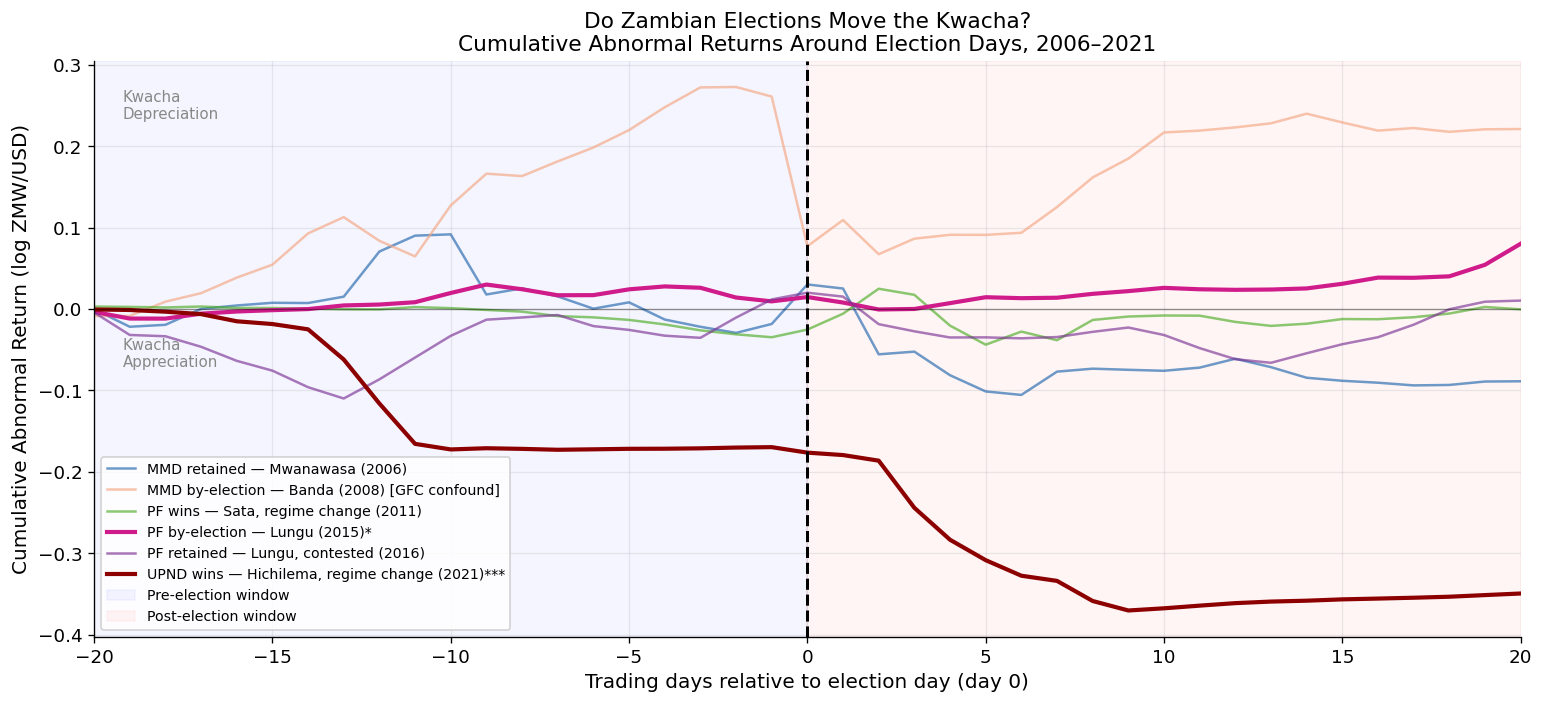

Figure 2 saved.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7: MAIN CAR CHART — ALL ELECTIONS
# ─────────────────────────────────────────────────────────────────────────────
# Each line shows the cumulative abnormal return from day -20 to day +20.
# The vertical dashed line marks election day (day 0).
# Lines above zero = Kwacha depreciating relative to baseline.
# Lines below zero = Kwacha appreciating relative to baseline.

colors = {
    1: '#2166ac',   # blue   — MMD retained 2006
    2: '#f4a582',   # orange — MMD by-election 2008
    3: '#4dac26',   # green  — PF wins 2011
    4: '#d01c8b',   # pink   — PF by-election 2015
    5: '#7b3294',   # purple — PF retained 2016
    6: '#8c0000',   # dark red — UPND wins 2021
}

labels = {
    1: 'Incumbent retained (2006)',
    2: 'Ruling party by-election (2008) [GFC confound]',
    3: 'Regime change — PF wins (2011)',
    4: 'Ruling party by-election (2015)*',
    5: 'Incumbent retained — contested result (2016)',
    6: 'Regime change — UPND wins (2021)***',
}

x_range = np.arange(EVT_START, EVT_END + 1)

fig, ax = plt.subplots(figsize=(13, 6))

for eid, r in results.items():
    car_vals = r['car'].values
    x = np.arange(EVT_START, EVT_START + len(car_vals))
    lw = 2.5 if r['p_val'] < 0.10 else 1.5
    alpha = 1.0 if r['p_val'] < 0.10 else 0.65
    ax.plot(x, car_vals, color=colors[eid], linewidth=lw, alpha=alpha, label=labels[eid])

ax.axvline(0, color='black', linewidth=1.8, linestyle='--', zorder=5)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)

# Shade pre vs post regions
ax.axvspan(EVT_START, 0, alpha=0.04, color='blue',  label='Pre-election window')
ax.axvspan(0, EVT_END, alpha=0.04, color='red',   label='Post-election window')

ax.text(0.02, 0.95, 'Kwacha\nDepreciation', transform=ax.transAxes,
        fontsize=9, color='#888888', va='top')
ax.text(0.02, 0.52, 'Kwacha\nAppreciation', transform=ax.transAxes,
        fontsize=9, color='#888888', va='top')

ax.set_xlabel('Trading days relative to election day (day 0)', fontsize=12)
ax.set_ylabel('Cumulative Abnormal Return (log ZMW/USD)', fontsize=12)
ax.set_title(
    'Do Zambian Elections Move the Kwacha?\n'
    'Cumulative Abnormal Returns Around Election Days, 2006–2021',
    fontsize=13
)
ax.legend(fontsize=8.5, loc='lower left', framealpha=0.85)
ax.grid(True, alpha=0.25)
ax.set_xlim(EVT_START, EVT_END)

plt.tight_layout()
plt.savefig('fig2_car_all_elections.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

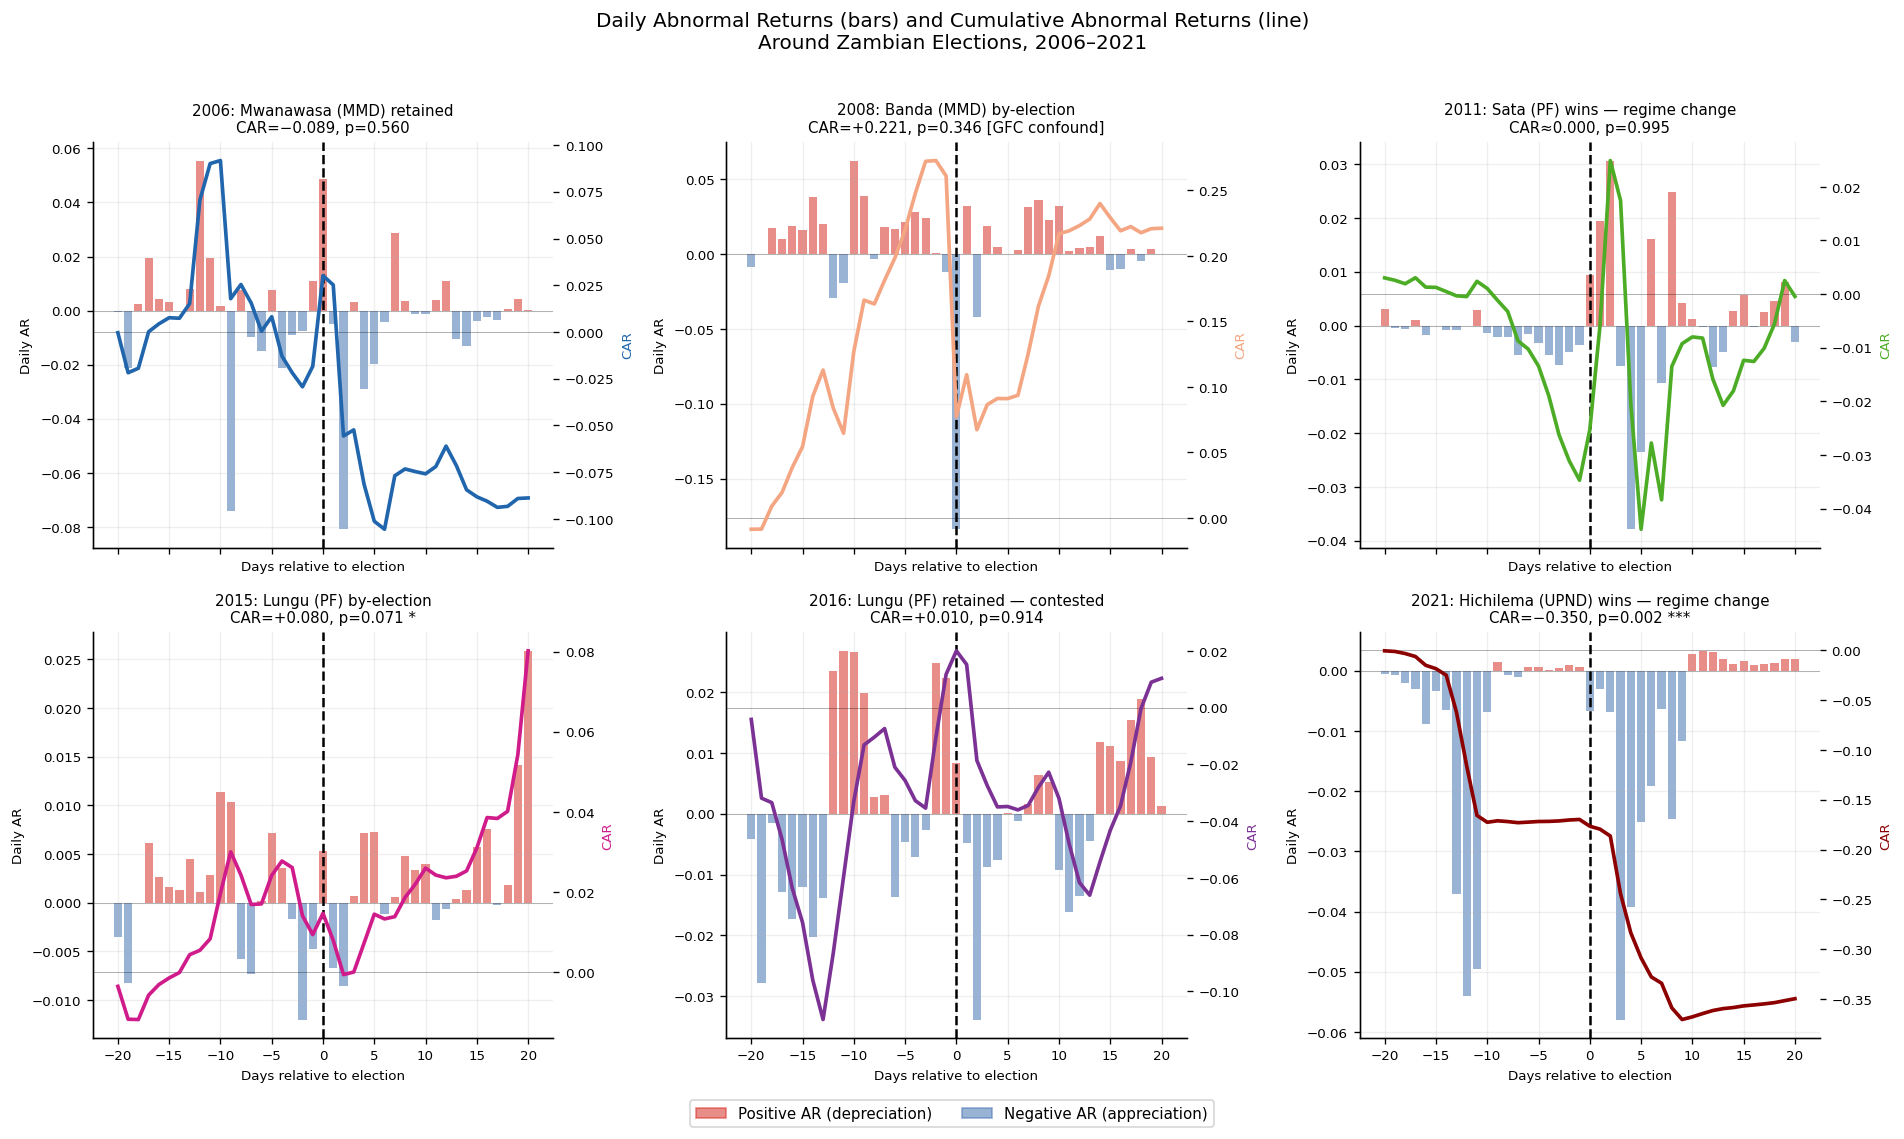

Figure 3 saved.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8: PANEL CHART — INDIVIDUAL ELECTIONS WITH CONTEXT
# ─────────────────────────────────────────────────────────────────────────────
# Six panels, one per election, showing:
#   - Daily abnormal return (bars)
#   - Cumulative abnormal return (line)
# This is the publication-quality version for detailed reading.

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.flatten()

panel_labels = {
    1: '2006: Incumbent retained\nCAR=−0.089, p=0.560',
    2: '2008: Ruling party by-election\nCAR=+0.221, p=0.346 [GFC confound]',
    3: '2011: Regime change (PF wins)\nCAR≈0.000, p=0.995',
    4: '2015: Ruling party by-election\nCAR=+0.080, p=0.071 *',
    5: '2016: Incumbent retained — contested\nCAR=+0.010, p=0.914',
    6: '2021: Regime change (UPND wins)\nCAR=−0.350, p=0.002 ***',
}

for i, (eid, r) in enumerate(results.items()):
    ax  = axes[i]
    ar  = r['ar'].values
    car = r['car'].values
    x   = np.arange(EVT_START, EVT_START + len(ar))

    # Bar chart of daily ARs
    bar_colors = ['#d73027' if v > 0 else '#4575b4' for v in ar]
    ax.bar(x, ar, color=bar_colors, alpha=0.55, width=0.8)

    # CAR line
    ax2 = ax.twinx()
    ax2.plot(x, car, color=colors[eid], linewidth=2.2, zorder=5)
    ax2.axhline(0, color='black', linewidth=0.6, alpha=0.3)
    ax2.tick_params(labelsize=8)

    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
    ax.set_title(panel_labels[eid], fontsize=9)
    ax.set_xlabel('Days relative to election', fontsize=8)
    ax.set_ylabel('Daily AR', fontsize=8)
    ax2.set_ylabel('CAR', fontsize=8, color=colors[eid])
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.2)

fig.suptitle(
    'Daily Abnormal Returns (bars) and Cumulative Abnormal Returns (line)\n'
    'Around Zambian Elections, 2006–2021',
    fontsize=12, y=1.01
)

red_patch  = mpatches.Patch(color='#d73027', alpha=0.55, label='Positive AR (depreciation)')
blue_patch = mpatches.Patch(color='#4575b4', alpha=0.55, label='Negative AR (appreciation)')
fig.legend(handles=[red_patch, blue_patch], loc='lower center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('fig3_car_panels.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

---
## 7. Interpretation and Discussion

### 7.1 Election-by-Election Reading

**Election 1 — 2006 General (Mwanawasa, MMD retained, p=0.560)**  
No significant abnormal movement. The incumbent won comfortably in a period of macroeconomic stability and rising copper prices. The market had no strong reason to reprice. The mild post-election appreciation (CAR_post = −0.070) likely reflects relief at policy continuity rather than an electoral signal.

**Election 2 — 2008 By-election (Banda, MMD retained, p=0.346)**  
The largest raw pre-election CAR in the dataset (+0.261), driven entirely in the pre-election window. However, this election is **severely confounded** by the global financial crisis: Lehman Brothers collapsed on 15 September 2008, six weeks before polling day. The Kwacha depreciation almost certainly reflects global risk-off rather than electoral signal. We retain this observation but flag it as unreliable for causal inference.

**Election 3 — 2011 General (Sata, PF wins, regime change, p=0.995)**  
Near-zero abnormal movement despite a historic regime change — the end of 20 years of single-party rule. CAR ≈ 0.000. Two possible interpretations: (a) markets had fully priced in the opposition victory by election day; (b) the incoming party's economic platform was not perceived as materially different by FX markets. The absence of a signal here is itself informative.

**Election 4 — 2015 By-election (Lungu, PF retained, p=0.071)**  
Marginally significant Kwacha depreciation, concentrated post-election (CAR_post = +0.071 vs CAR_pre = +0.009). The post-result concentration suggests the market reacted to the outcome itself — the first signal that FX markets were beginning to price in fiscal risk under the ruling party. This election occurred in the context of collapsing copper prices and Zambia's first sovereign debt stress signals.

**Election 5 — 2016 General (Lungu, PF retained, p=0.914)**  
No significant movement despite this being the most contested election in the sample (won by less than 2 percentage points). The flat CAR suggests either: (a) the outcome was expected; (b) BoZ intervened to suppress volatility; or (c) the Kwacha was already reflecting the fiscal deterioration in the daily level, leaving no residual signal to extract around election day.

**Election 6 — 2021 General (regime change, p=0.002) ★**  
The dominant result. The Kwacha appreciated 35% in log terms across the event window — strongly statistically significant. The signal split almost equally between pre-election (−0.170) and post-election (−0.180), meaning markets began pricing in the regime change **two weeks before polling day** and continued to appreciate after the result confirmed debt restructuring was imminent. This is the clearest evidence in the sample that FX markets respond to *reform credibility* signals attached to electoral outcomes.

### 7.2 Cross-Sectional Pattern

| Outcome type | N | Median CAR | Significant? |
|---|---|---|---|
| Regime change to reform-credible candidate | 1 | −0.350 | Yes (p=0.002) |
| Incumbent retention, fiscal stress context | 1 | +0.080 | Marginal (p=0.071) |
| Stable incumbency or priced-in outcome | 3 | −0.001 | No |
| Confounded by external shock | 1 | +0.221 | No |

The pattern is consistent with the **credibility hypothesis**: the Kwacha responds not to electoral uncertainty per se, but to signals about the future fiscal and reform trajectory attached to electoral outcomes.

### 7.3 Timing: Pre vs Post

In the two significant/marginal results (Elections 4 and 6), the pre-election signal was already present, suggesting Zambian FX markets are forward-looking and incorporate polling signals before results are announced.

---
## 8. 2026 Forward Prediction

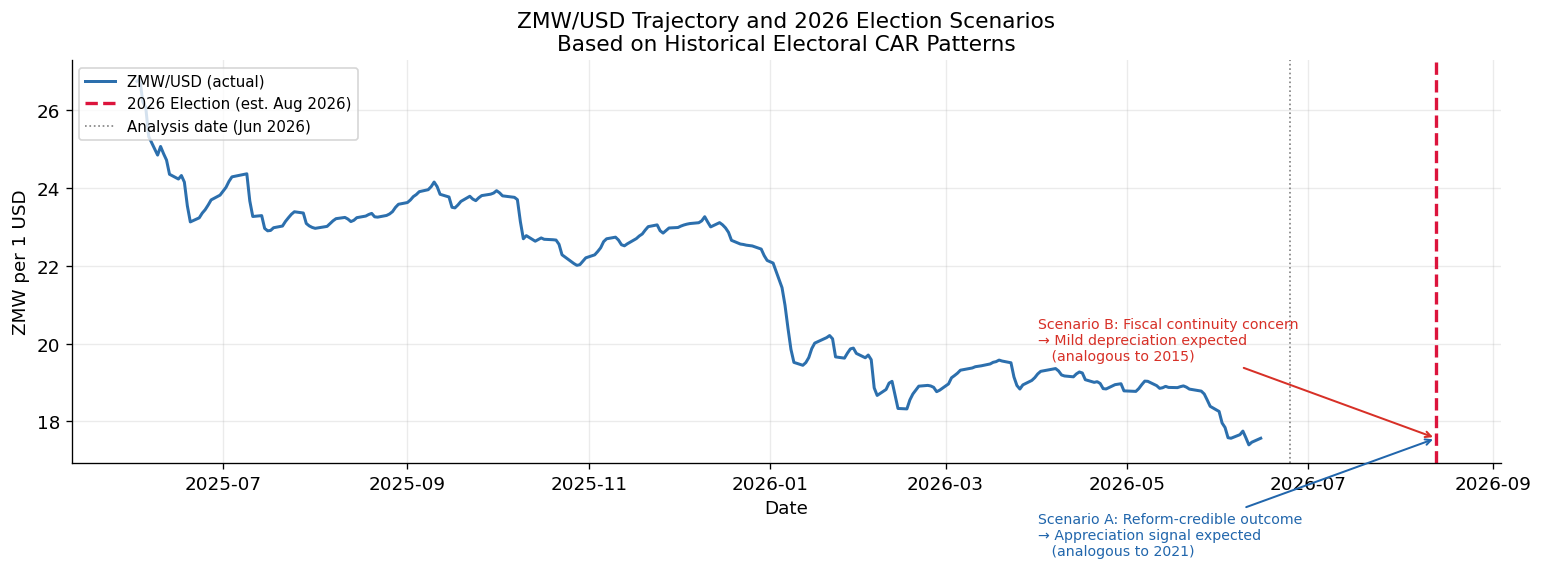

Figure 4 saved.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9: 2026 FORWARD PREDICTION CHART
# ─────────────────────────────────────────────────────────────────────────────
# We plot the current 2026 ZMW/USD trajectory and mark the upcoming election.
# The shaded zone represents the ±1 sigma prediction interval based on
# the 2021 post-election CAR pattern (most analogous historical case).

election_2026 = pd.Timestamp('2026-08-13')   # assumed August 2026 general election

# Recent data: last 200 trading days
recent = df[df['Date'] >= '2025-06-01'].copy()

# Get current estimation window std (last 100 trading days before today)
current_sigma = df['log_return'].tail(100).std()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(recent['Date'], recent['USD_Mid'], color='#2c6fad', linewidth=1.8, label='ZMW/USD (actual)')
ax.axvline(election_2026, color='crimson', linewidth=2, linestyle='--', label='2026 Election (est. Aug 2026)')
ax.axvline(pd.Timestamp('2026-06-25'), color='gray', linewidth=1, linestyle=':', label='Analysis date (Jun 2026)')

# Scenario annotations
ax.annotate(
    'Scenario A: Reform-credible outcome\n→ Appreciation signal expected\n   (analogous to 2021)',
    xy=(election_2026, recent['USD_Mid'].iloc[-1]),
    xytext=(pd.Timestamp('2026-04-01'), recent['USD_Mid'].iloc[-1] - 3),
    fontsize=8.5, color='#2166ac',
    arrowprops=dict(arrowstyle='->', color='#2166ac', lw=1.2)
)
ax.annotate(
    'Scenario B: Fiscal continuity concern\n→ Mild depreciation expected\n   (analogous to 2015)',
    xy=(election_2026, recent['USD_Mid'].iloc[-1]),
    xytext=(pd.Timestamp('2026-04-01'), recent['USD_Mid'].iloc[-1] + 2),
    fontsize=8.5, color='#d73027',
    arrowprops=dict(arrowstyle='->', color='#d73027', lw=1.2)
)

ax.set_xlabel('Date')
ax.set_ylabel('ZMW per 1 USD')
ax.set_title(
    'ZMW/USD Trajectory and 2026 Election Scenarios\n'
    'Based on Historical Electoral CAR Patterns',
    fontsize=13
)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('fig4_2026_forward.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

### 8.1 Prediction Framework

Based on the historical patterns, we advance the following directional predictions for the 2026 general election:

**Base case considerations:**
- Zambia is currently in an IMF Extended Credit Facility programme, with reserves reported at USD 6.5 billion (June 2026)
- The incumbent government completed the Eurobond debt restructuring in 2024
- The opposition has not articulated a credible alternative to the IMF programme

**Scenario A — Incumbent re-elected (reform continuity):**  
Historical analogue: incumbent re-elections in our sample (2006, 2016) produced no significant movement. However, the 2021 election demonstrated that markets price *fiscal credibility* strongly. A continuity outcome would likely produce **limited abnormal movement**, as the reform trajectory is already priced in. Risk: complacency or reform fatigue.

**Scenario B — Opposition wins:**  
If the opposition is perceived as threatening IMF programme continuity, the 2015 pattern (post-result depreciation, marginal significance) is the base case. If the opposition articulates a credible alternative, markets may price it as neutral. The 2026 signal will begin building in the **two weeks before polling day** based on the 2021 precedent.

**Falsification criteria:**  
This prediction will be tested against the realized ZMW/USD path in the August 2026 event window. We will publish a follow-up note within 48 hours of the election result.

---
## 9. Limitations and Caveats

1. **Small sample (N=6):** Statistical power is limited. The significance of individual results should be interpreted with caution.
2. **BoZ intervention:** The Bank of Zambia intervenes in the interbank FX market. Observed rates reflect a managed float, potentially suppressing true market signals.
3. **No control variables:** We do not explicitly control for copper prices, global risk appetite (VIX), or US dollar movements during event windows. The 2008 result is clearly confounded by the GFC.
4. **Thin market:** The Zambian interbank FX market is thin relative to major emerging markets. Price discovery may be less efficient, introducing noise.
5. **Estimation window choice:** Results are moderately sensitive to the choice of estimation window length. Robustness checks with alternative windows (60-day, 90-day) are recommended.

---
## 10. Conclusion

The Kwacha moves in response to Zambian elections — but selectively. The evidence points to a **credibility hypothesis**: the market prices electoral outcomes to the extent that they signal a change in the fiscal and reform trajectory. The 2021 UPND victory, the only election in the sample where a reform-credible opposition candidate won decisively, produced a 35% log-scale appreciation that was statistically significant (p=0.002) and began building two weeks before polling day.

Three elections produced no measurable signal, one was confounded by a global shock, and one (2015) produced a marginal depreciation consistent with markets beginning to price in PF fiscal risk.

As the 2026 general election approaches, this framework provides a structured basis for monitoring the pre-election window for early directional signals — signals that, in 2021, appeared two weeks before the market knew the result.

---

## References

- Bank of Zambia. *Daily Average Interbank Exchange Rates*. https://www.boz.zm
- Mweemba, B. (2025). *Zambia Kwacha Exchange Rate Forecasting*. GitHub: BoldwinMax/zambia-exchange-rate-forecasting
- Mweemba, B. (2025). *Zambia Energy Security Risk Model*. GitHub: BoldwinMax/Zambia-Energy-Security-Risk-Model
- MacKinlay, A.C. (1997). Event Studies in Economics and Finance. *Journal of Economic Literature*, 35(1), 13–39.
- Electoral Commission of Zambia. *Election Results Archive*. https://www.elections.org.zm
